Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 142MB/s]


Layer 0: Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 64, 224, 224])


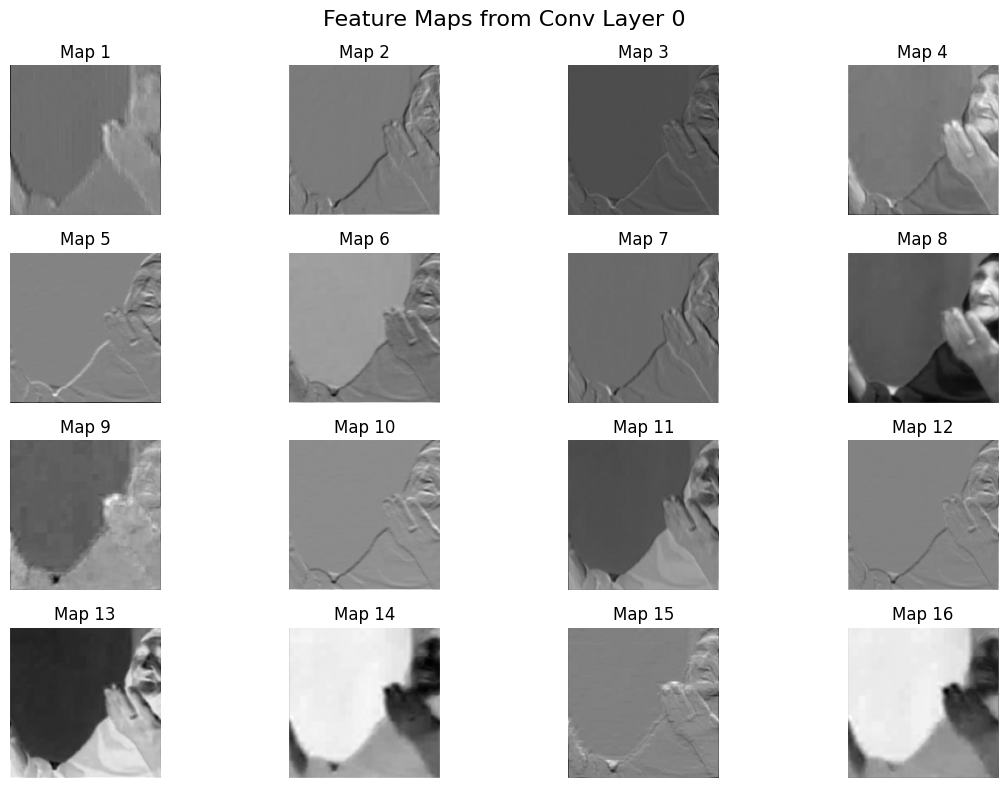

Layer 2: Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 64, 224, 224])


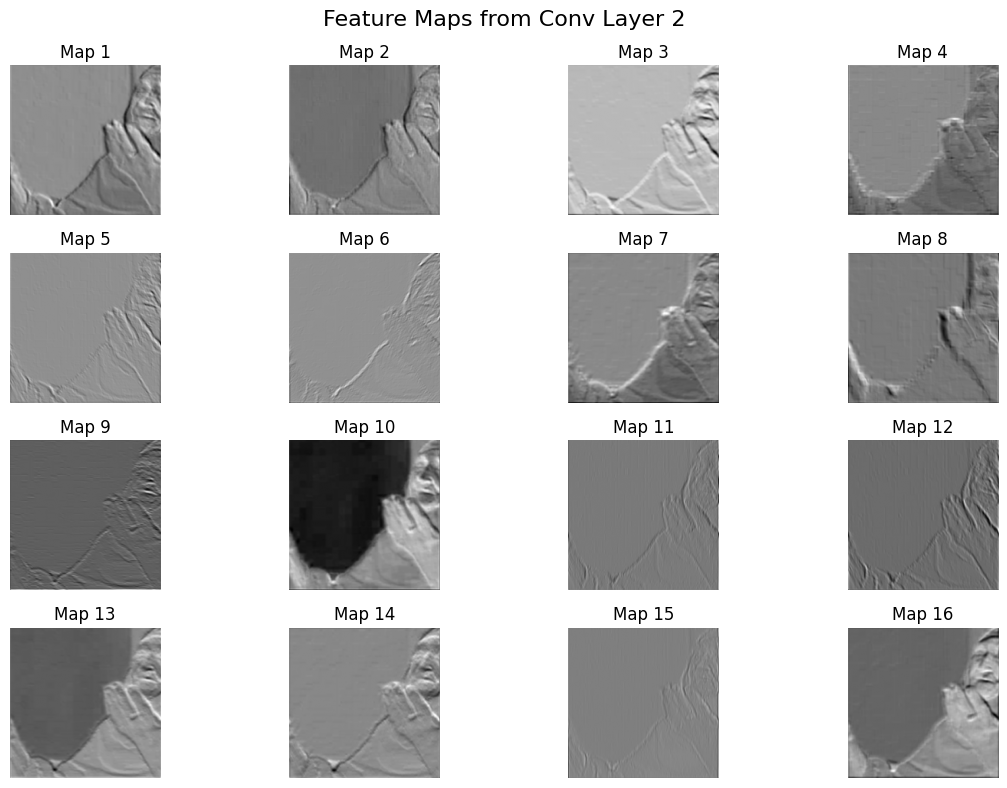

Layer 5: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 128, 112, 112])


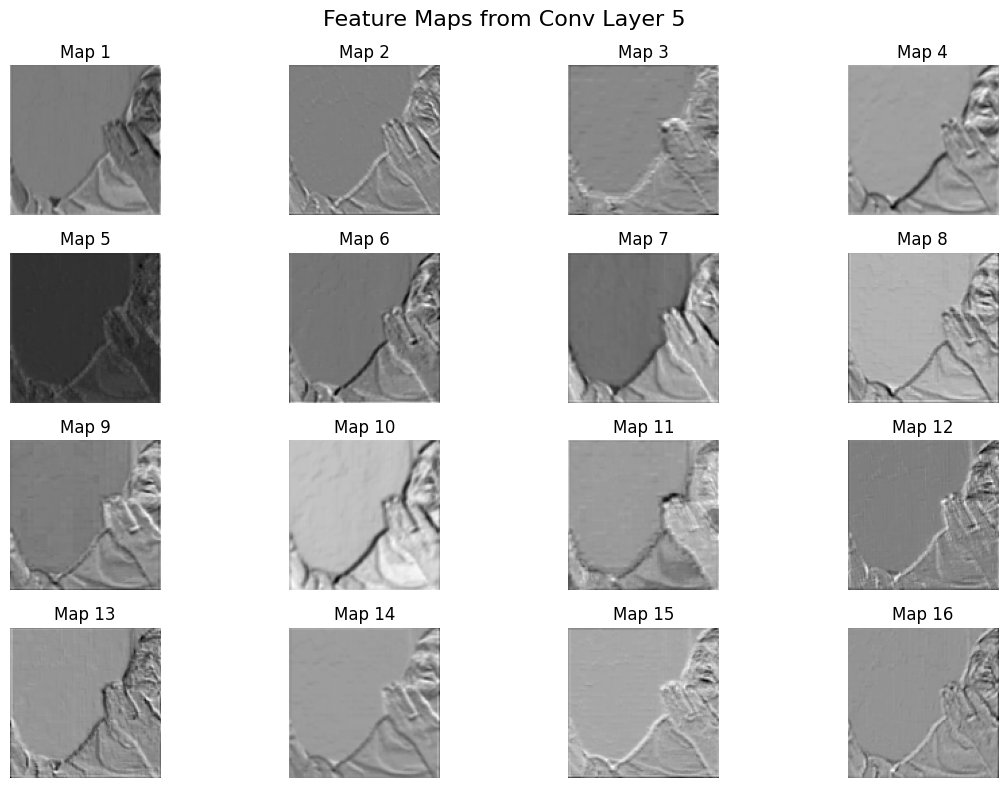

Layer 7: Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 128, 112, 112])


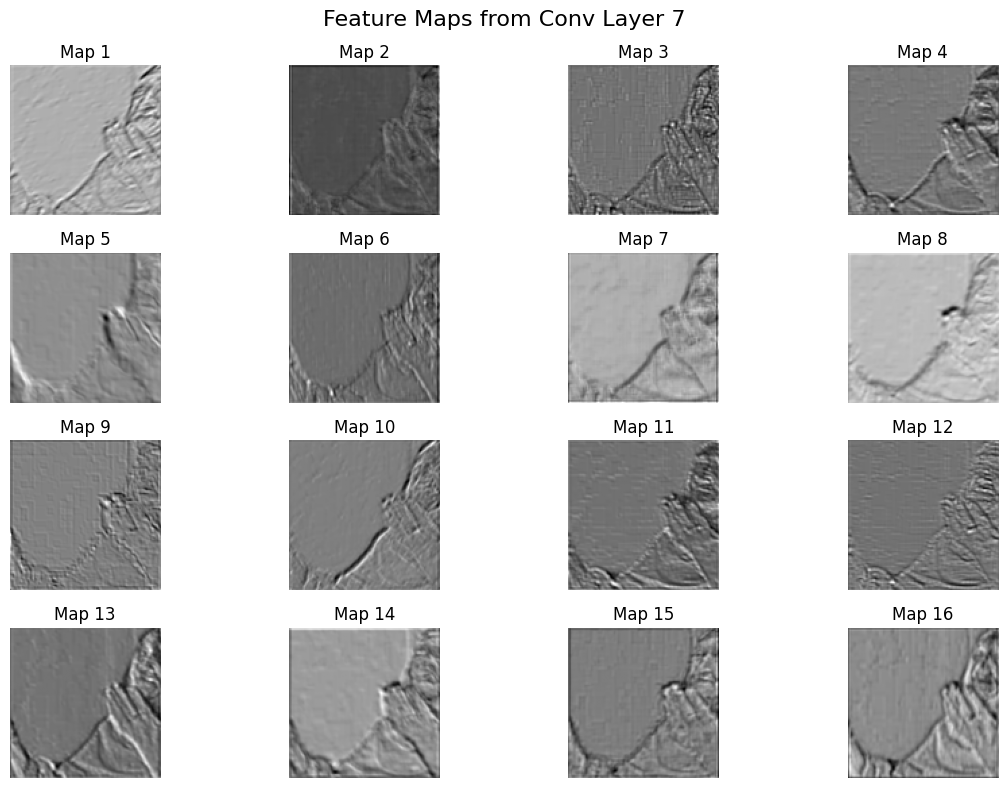

Layer 10: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 256, 56, 56])


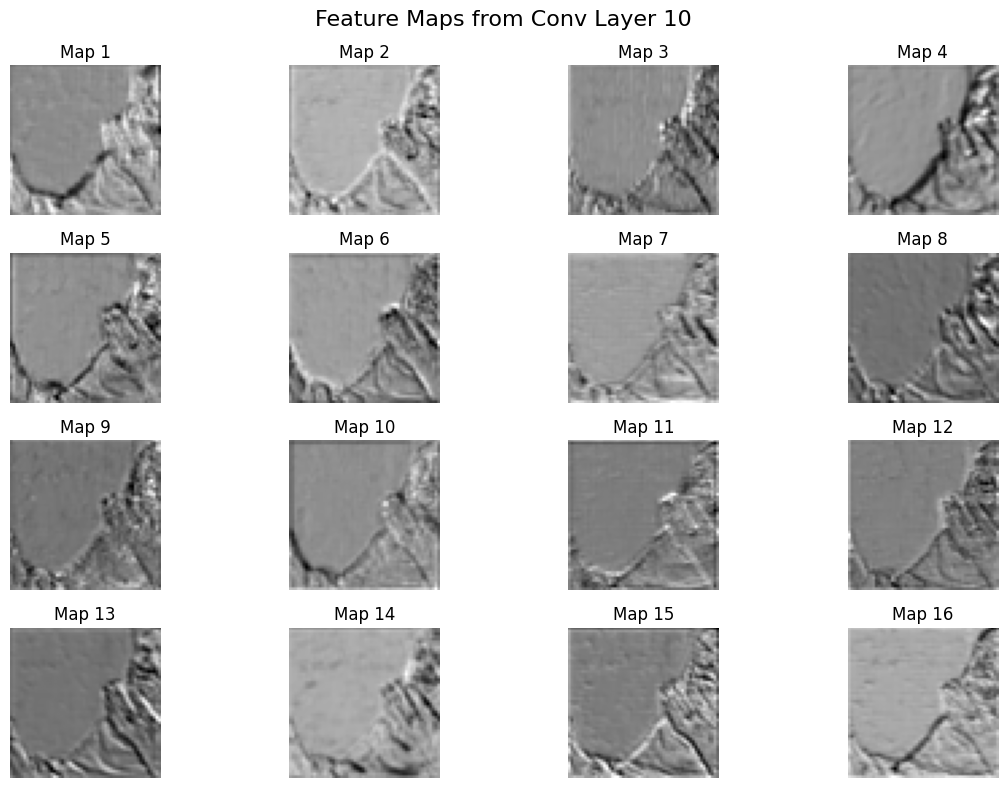

Layer 12: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 256, 56, 56])


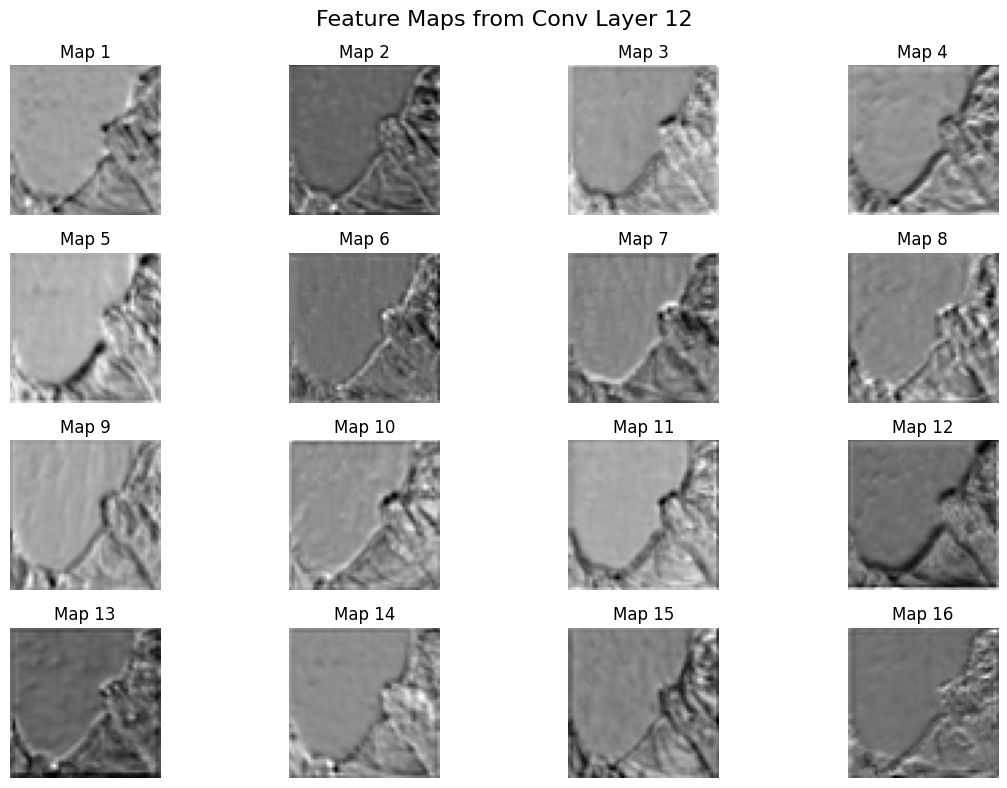

Layer 14: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 256, 56, 56])


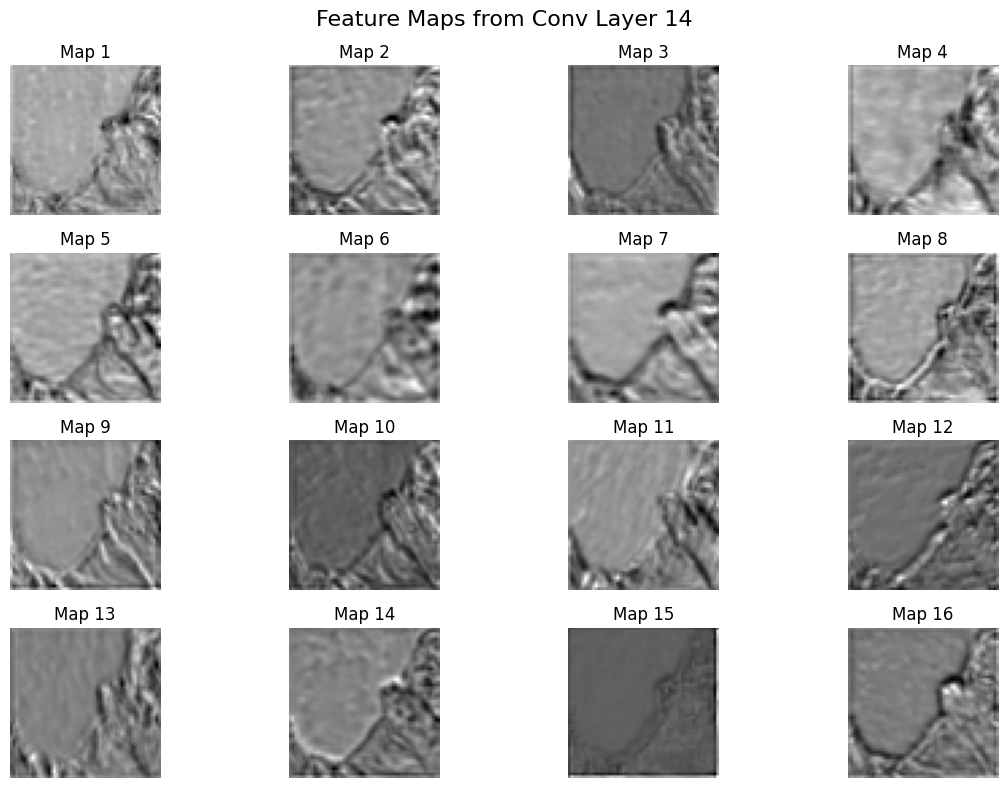

Layer 17: Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 28, 28])


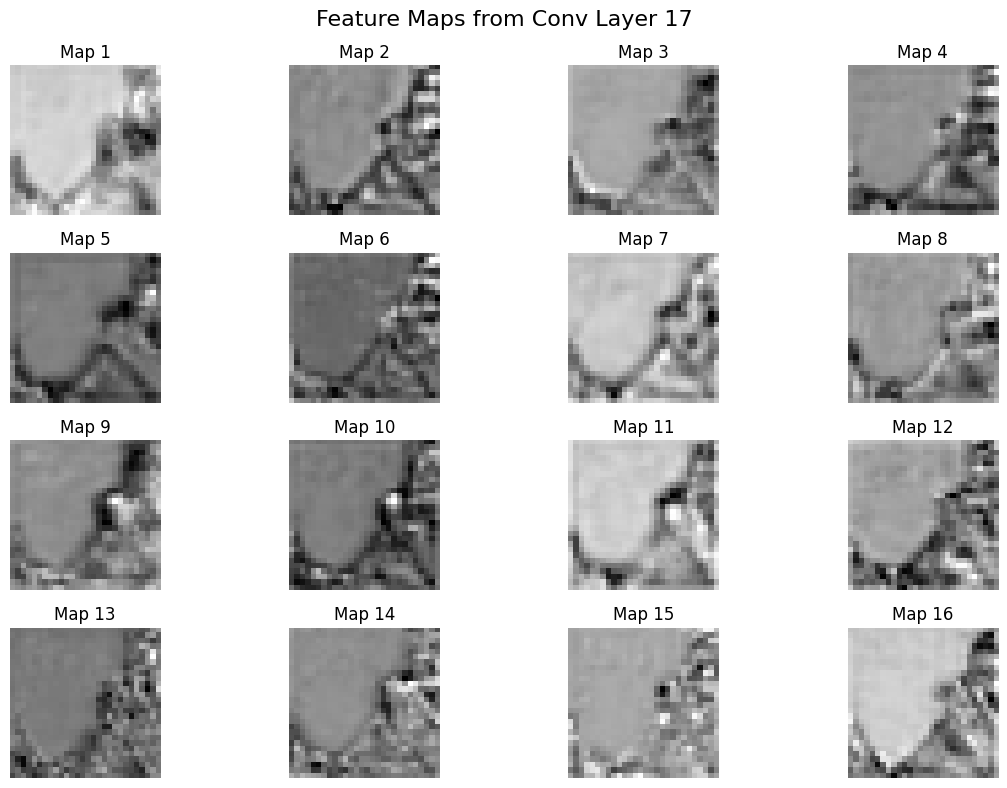

Layer 19: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 28, 28])


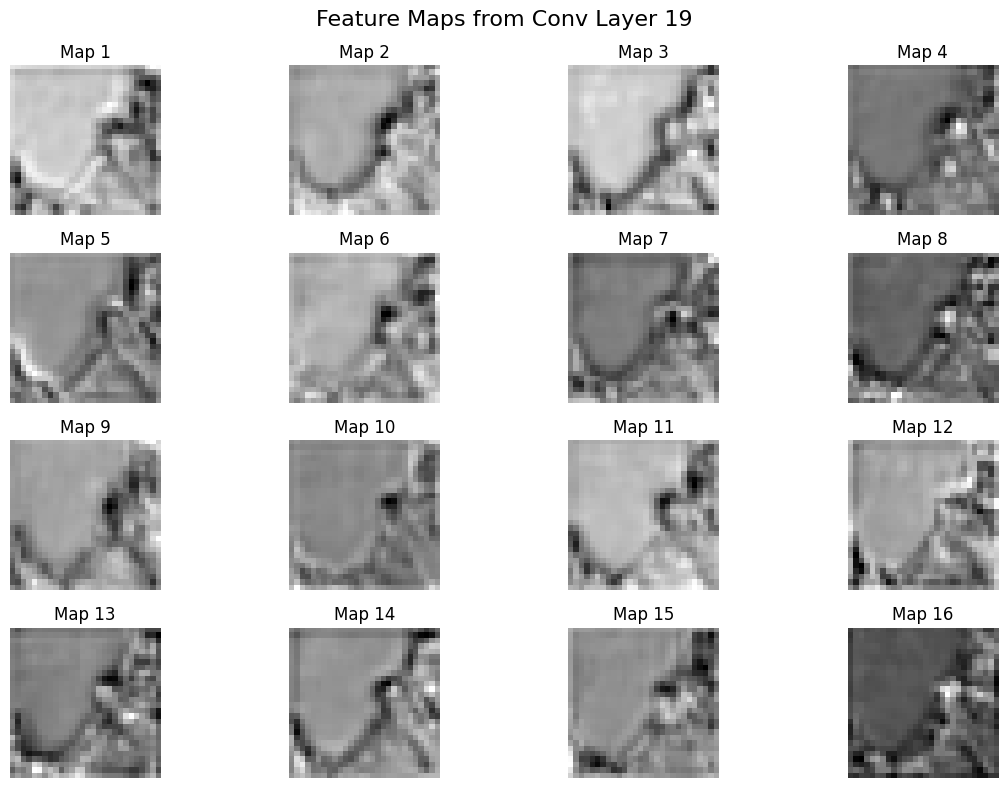

Layer 21: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 28, 28])


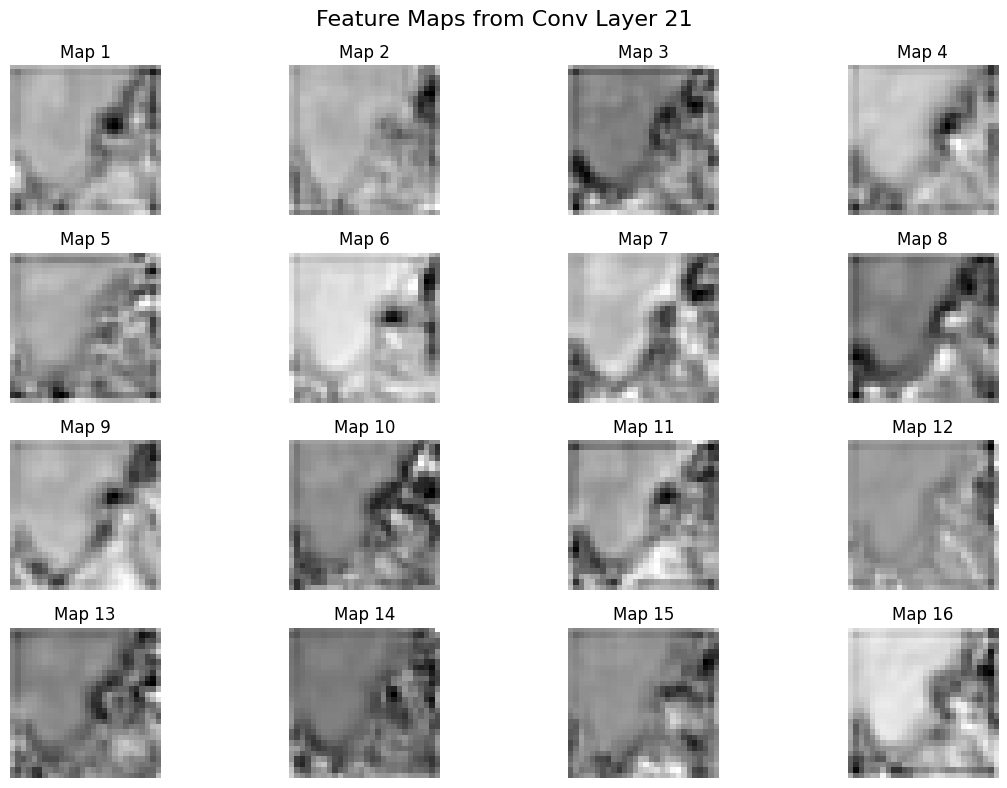

Layer 24: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 14, 14])


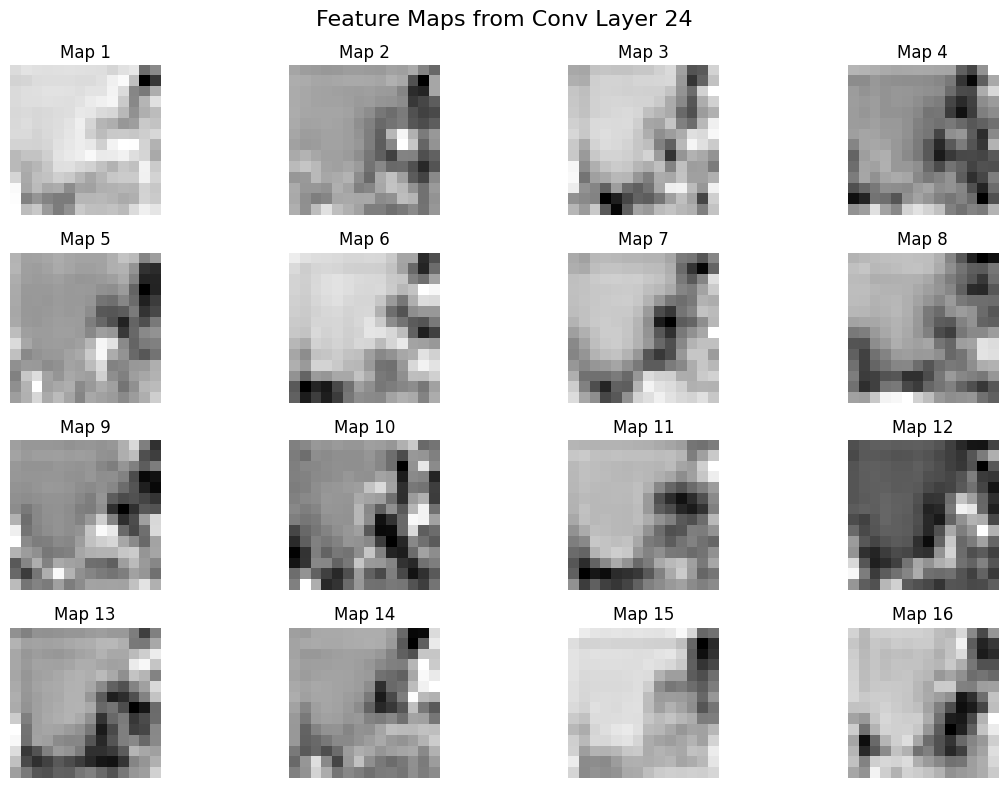

Layer 26: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 14, 14])


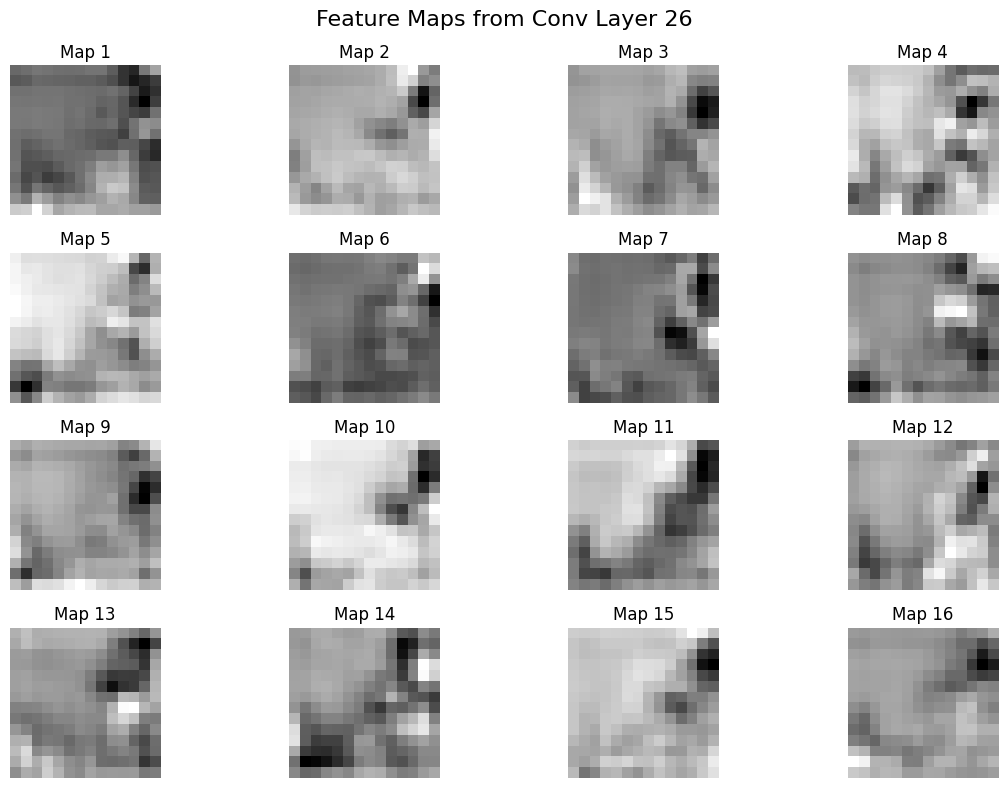

Layer 28: Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
Output shape: torch.Size([1, 512, 14, 14])


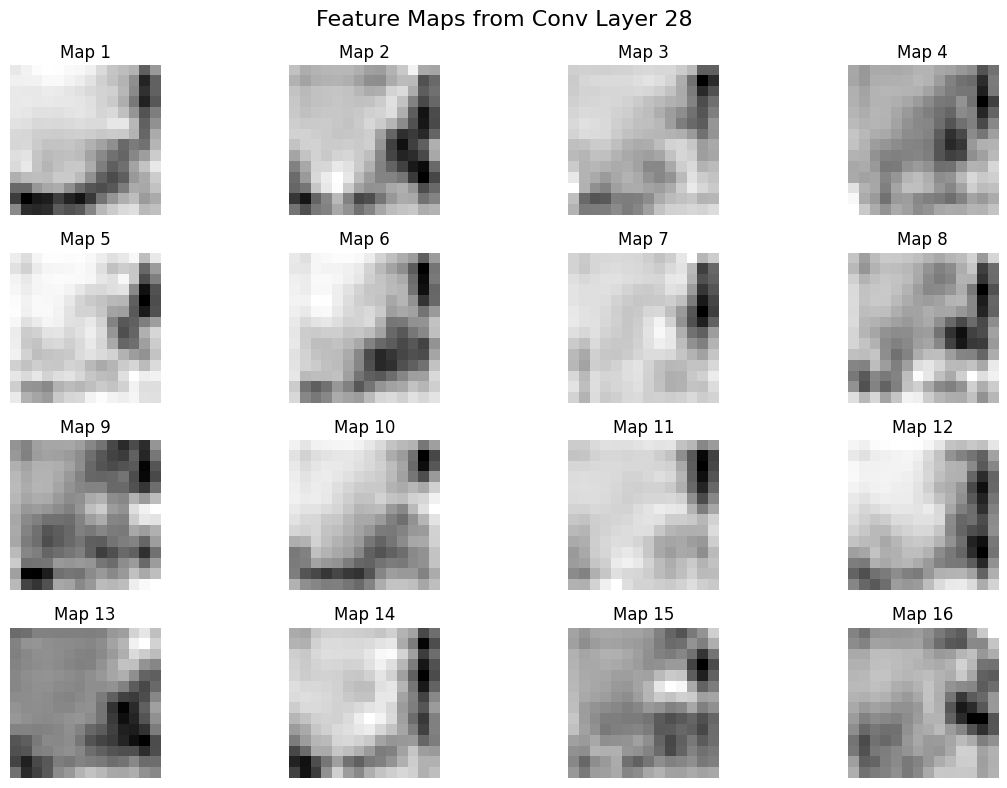

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image

from torchvision import models, transforms
from torchvision.models import VGG16_Weights


# =========================
# 1. Load image
# =========================
image_path = "/content/Untitled.png"  # change this

image = Image.open(image_path).convert("RGB")


# =========================
# 2. Preprocess image
# =========================
weights = VGG16_Weights.IMAGENET1K_V1
preprocess = weights.transforms()

input_tensor = preprocess(image).unsqueeze(0)


# =========================
# 3. Load pretrained VGG16
# =========================
model = models.vgg16(weights=weights)
model.eval()


# We only need convolutional feature extractor
features = model.features


# =========================
# 4. Function to show feature maps
# =========================
def show_feature_maps(feature_map, layer_name, max_maps=16):
    """
    feature_map shape:
    [batch_size, channels, height, width]
    """

    feature_map = feature_map.squeeze(0)

    num_maps = min(max_maps, feature_map.shape[0])

    plt.figure(figsize=(12, 8))
    plt.suptitle(f"Feature Maps from {layer_name}", fontsize=16)

    for i in range(num_maps):
        fmap = feature_map[i].detach().cpu()

        # Normalize for visualization
        fmap = (fmap - fmap.min()) / (fmap.max() - fmap.min() + 1e-8)

        plt.subplot(4, 4, i + 1)
        plt.imshow(fmap, cmap="gray")
        plt.axis("off")
        plt.title(f"Map {i+1}")

    plt.tight_layout()
    plt.show()


# =========================
# 5. Pass image layer by layer
# =========================
x = input_tensor

for layer_index, layer in enumerate(features):
    x = layer(x)

    # Show only convolution layers
    if isinstance(layer, torch.nn.Conv2d):
        print(f"Layer {layer_index}: {layer}")
        print("Output shape:", x.shape)

        show_feature_maps(
            feature_map=x,
            layer_name=f"Conv Layer {layer_index}",
            max_maps=16
        )